#### 1. Introduction
Text classification - assigning a label (positive/negative) to next
Why is this hard? Machines don't understand words - they need numbers. So we need
1. A way to represent text as numbers (BoW/ TF-IDF)
2. A classifier that learns from those numbers (Naive Bayers)

#### 2. Theory 
Bag of Words (BoW)
- Represents a document as a vector of word frequencies
- Ignores grammer & order - Just which words appear and how often
- Problem: common words like "the", "movie" dominate even if they carry no sentiment 

TF-IDF (Term Frequency - Inverse Document Frequency)
- TF → how often term t appears in document d
- IDF → penalizes terms that appear in many documents
- Result: rare-but-meaningful words get higher weight 

Naïve Bayes (Multinomial)

Based on Bayes' theorem:

1. "Naïve" assumption: all words are independent given the class (false in reality, but works surprisingly well).
2. Multinomial NB is the variant designed for word-count / TF-IDF features.

##### Step 1 - Import Libraries 

In [8]:
import nltk
import string
import re
from nltk.corpus import movie_reviews, stopwords
from nltk.stem import WordNetLemmatizer # preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer # does tokenization + TF-IDF in one step.
from sklearn.naive_bayes import MultinomialNB # the right NB variant for TF-IDF features.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

### Code Explanation (Step-by-Step)

- `import nltk` → imports required library.
- `import string` → imports required library.
- `import re` → imports required library.
- `from nltk.corpus import movie_reviews, stopwords` → executes step.
- `from nltk.stem import WordNetLemmatizer # preprocessing` → executes step.
- `from sklearn.feature_extraction.text import TfidfVectorizer # does tokenization + TF-IDF in one step.` → executes step.
- `from sklearn.naive_bayes import MultinomialNB # the right NB variant for TF-IDF features.` → executes step.
- `from sklearn.model_selection import train_test_split` → executes step.
- `from sklearn.metrics import accuracy_score, confusion_matrix, classification_report` → executes step.
- `import matplotlib.pyplot as plt` → imports required library.
- `import seaborn as sns` → imports required library.


##### Step 2 - Download NLTK Data

In [3]:
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\14jay\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\14jay\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Zip Slip blocked: stopwords/
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\14jay\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\14jay\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Zip Slip blocked: punkt/


False

### Code Explanation (Step-by-Step)

- `nltk.download('movie_reviews')` → executes step.
- `nltk.download('stopwords')` → executes step.
- `nltk.download('wordnet')` → executes step.
- `nltk.download('punkt')` → executes step.


##### Step 3 - Load the Dataset

In [4]:
documents = [
    (" ".join(movie_reviews.words(fileid)), category)
    for category in movie_reviews.categories()
    for fileid in movie_reviews.fileids(category)
]

print("Total reviews:", len(documents))
print("Categories:", movie_reviews.categories())
print("Sample:", documents[0][1], "→", documents[0][0][:200])

Total reviews: 2000
Categories: ['neg', 'pos']
Sample: neg → plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . what


### Code Explanation (Step-by-Step)

- `documents = [` → assigns value.
- `(" ".join(movie_reviews.words(fileid)), category)` → executes step.
- `for category in movie_reviews.categories()` → loop to iterate.
- `for fileid in movie_reviews.fileids(category)` → loop to iterate.
- `]` → executes step.
- `print("Total reviews:", len(documents))` → prints output.
- `print("Categories:", movie_reviews.categories())` → prints output.
- `print("Sample:", documents[0][1], "→", documents[0][0][:200])` → prints output.


##### Step 4 - Preprocessing

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]','', text) # remove punctuation/ digits
    tokens = text.split() # tokenize
    tokens = [t for t in tokens if t not in stop_words] # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatize
    return " ".join(tokens)

texts = [preprocess(doc) for doc, label in documents]
labels = [label for doc, label in documents]


print("Before:", documents[0][0][:150])
print("After :", texts[0][:150])

Before: plot : two teen couples go to a church party , drink and then drive . they get into an accident . one of the guys dies , but his girlfriend continues 
After : plot two teen couple go church party drink drive get accident one guy dy girlfriend continues see life nightmare deal watch movie sorta find critique 


### Code Explanation (Step-by-Step)

- `stop_words = set(stopwords.words('english'))` → assigns value.
- `lemmatizer = WordNetLemmatizer()` → assigns value.
- `def preprocess(text):` → defines a function.
- `text = text.lower()` → assigns value.
- `text = re.sub(r'[^a-z\s]','', text) # remove punctuation/ digits` → assigns value.
- `tokens = text.split() # tokenize` → assigns value.
- `tokens = [t for t in tokens if t not in stop_words] # remove stopwords` → assigns value.
- `tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatize` → assigns value.
- `return " ".join(tokens)` → returns result.
- `texts = [preprocess(doc) for doc, label in documents]` → assigns value.
- `labels = [label for doc, label in documents]` → assigns value.
- `print("Before:", documents[0][0][:150])` → prints output.
- `print("After :", texts[0][:150])` → prints output.


##### Step 5: TF-IDF Vectorization

In [9]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X = vectorizer.fit_transform(texts)
y = labels

print("Shape of TG-IDF matrix: ", X.shape)
print("Sample features:", vectorizer.get_feature_names_out()[:20])

Shape of TG-IDF matrix:  (2000, 5000)
Sample features: ['abandon' 'abandoned' 'ability' 'able' 'aboard' 'absence' 'absent'
 'absolute' 'absolutely' 'absolutely nothing' 'absurd' 'abuse' 'abyss'
 'academy' 'academy award' 'accent' 'accept' 'acceptable' 'accepts'
 'accident']


### Code Explanation (Step-by-Step)

- `vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))` → assigns value.
- `X = vectorizer.fit_transform(texts)` → assigns value.
- `y = labels` → assigns value.
- `print("Shape of TG-IDF matrix: ", X.shape)` → prints output.
- `print("Sample features:", vectorizer.get_feature_names_out()[:20])` → prints output.


##### Step 6: Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 1600
Test size : 400


### Code Explanation (Step-by-Step)

- `X_train, X_test, y_train, y_test = train_test_split(` → assigns value.
- `X, y, test_size=0.2, random_state=42, stratify=y` → assigns value.
- `)` → executes step.
- `print("Train size:", X_train.shape[0])` → prints output.
- `print("Test size :", X_test.shape[0])` → prints output.


##### Step 7: Train Naive Bayers

In [11]:
model = MultinomialNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


### Code Explanation (Step-by-Step)

- `model = MultinomialNB()` → assigns value.
- `model.fit(X_train, y_train)` → executes step.


##### Step 8: Predict + Evaluate 

In [12]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels= ['pos', 'neg'])

print(f"Accracy: {acc: 4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accracy:  0.805000

Classification Report:
               precision    recall  f1-score   support

         neg       0.79      0.83      0.81       200
         pos       0.82      0.78      0.80       200

    accuracy                           0.81       400
   macro avg       0.81      0.80      0.80       400
weighted avg       0.81      0.81      0.80       400



### Code Explanation (Step-by-Step)

- `y_pred = model.predict(X_test)` → assigns value.
- `acc = accuracy_score(y_test, y_pred)` → assigns value.
- `cm = confusion_matrix(y_test, y_pred, labels= ['pos', 'neg'])` → assigns value.
- `print(f"Accracy: {acc: 4f}")` → prints output.
- `print("\nClassification Report:\n", classification_report(y_test, y_pred))` → prints output.


##### Step 9: Visualize Confusion Matrix

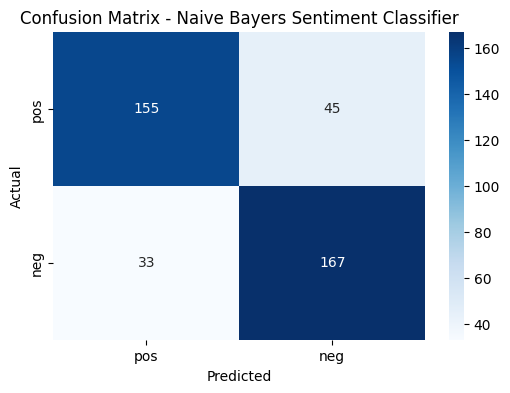

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt = 'd', cmap= "Blues", xticklabels=['pos', 'neg'], yticklabels=['pos', 'neg'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayers Sentiment Classifier")
plt.show()

### Code Explanation (Step-by-Step)

- `plt.figure(figsize=(6,4))` → assigns value.
- `sns.heatmap(cm, annot=True, fmt = 'd', cmap= "Blues", xticklabels=['pos', 'neg'], yticklabels=['pos', 'neg'])` → assigns value.
- `plt.xlabel("Predicted")` → executes step.
- `plt.ylabel("Actual")` → executes step.
- `plt.title("Confusion Matrix - Naive Bayers Sentiment Classifier")` → executes step.
- `plt.show()` → executes step.


##### Step 10 - Test on Custom Reviews

In [15]:
custom_reviews = [
    "This movie was absolutely brilliant and the acting was superb!",
    "Terrible plot, boring characters, I regret watching this."
]

custom_clean = [preprocess(r) for r in custom_reviews]
custom_vec = vectorizer.transform(custom_clean)
predictions = model.predict(custom_vec)

for review, pred in zip(custom_reviews, predictions):
    print(f"[{pred.upper()}] {review}")


[POS] This movie was absolutely brilliant and the acting was superb!
[NEG] Terrible plot, boring characters, I regret watching this.


### Code Explanation (Step-by-Step)

- `custom_reviews = [` → assigns value.
- `"This movie was absolutely brilliant and the acting was superb!",` → executes step.
- `"Terrible plot, boring characters, I regret watching this."` → executes step.
- `]` → executes step.
- `custom_clean = [preprocess(r) for r in custom_reviews]` → assigns value.
- `custom_vec = vectorizer.transform(custom_clean)` → assigns value.
- `predictions = model.predict(custom_vec)` → assigns value.
- `for review, pred in zip(custom_reviews, predictions):` → loop to iterate.
- `print(f"[{pred.upper()}] {review}")` → prints output.


#### Conclusion 

1. TF-IDF gave better weighting than raw BoW because it suppressed generic words.
2. Multinomial NB handles sparse high-dim features efficiently.
3. Accuracy around 80–85% is typical - the "naïve" independence assumption still works because the signal is distributed across many words.
4. Bigrams (ngram_range=(1,2)) help capture negation like "not good".